# **Abstractive News Summarisation using BART Model**

It is an NLP system that generates short summaries by understanding the meaning of a news article and rewriting it in its own words, rather than copying exact sentences from the original text. It works like a human who reads a long article, identifies key ideas, and explains them in a concise and simpler form.

Unlike extractive methods that only select existing sentences, abstractive summarization uses transformer-based models to interpret context, rephrase information, and generate new coherent sentences. In this project, we use BART (Bidirectional and Auto-Regressive Transformers), a powerful sequence-to-sequence model that combines **bidirectional encoding and autoregressive decoding to produce high-quality summaries.**

**BART** is especially effective for summarization tasks as it is **pre-trained using a denoising objective, enabling it to reconstruct meaningful text from corrupted input**. This helps it generate fluent, context-aware, and human-like summaries while preserving the main ideas of the news article.


## 1. Setting Up Environment

This section installs and imports all the required libraries used throughout the project. The implementation relies on the Hugging Face Transformers library for loading the BART summarization model and tokenizer, while PyTorch serves as the deep learning backend for model inference.

Additional libraries such as Pandas and NumPy are used for data handling and preprocessing, whereas **NLTK supports sentence tokenization during text processing.** The **ROUGE evaluation metric** is included to assess the quality of generated summaries by **comparing them with reference summaries.** Visualisation libraries including Matplotlib and Seaborn are imported to support exploratory data analysis and result visualisation.

In [65]:
# Install required libraries.
# Run this cell once at the start of each Kaggle session.
!pip install -q transformers datasets rouge-score sentencepiece nltk

# Print installed versions for reproducibility.
import transformers, datasets, rouge_score, torch, nltk
print(f"transformers : {transformers.__version__}")
print(f"torch : {torch.__version__}")
print(f"GPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name : {torch.cuda.get_device_name(0)}")


# Standard data handling libraries.
import pandas as pd
import numpy as np
import re
import unicodedata
import warnings
import json
from datetime import datetime
warnings.filterwarnings('ignore')

# Hugging Face Transformers for BART model and tokeniser.
from transformers import BartTokenizer, BartForConditionalGeneration

# ROUGE metric for evaluating summary quality.
from rouge_score import rouge_scorer

# Progress bar for long loops.
from tqdm.auto import tqdm

# PyTorch for the deep learning backend.
import torch

# NLTK for sentence tokenisation during preprocessing.
import nltk
#nltk.download('punkt', quiet=True)
#nltk.download('punkt_tab', quiet=True)

nltk.download('punkt')
nltk.download('punkt_tab')


from nltk.tokenize import sent_tokenize

# Visualisation libraries.
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent visual style for all plots.
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print("All libraries are imported successfully.")

transformers : 5.0.0
torch : 2.10.0+cu128
GPU available : True
GPU name : Tesla T4
All libraries are imported successfully.


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 2. Configuration + Hyperparameters 

This section defines the configuration parameters used for the **BART-based abstractive news summarization model**. The project uses the **pre-trained `facebook/bart-large-cnn` model**, which has been specifically fine-tuned for summarization tasks on the CNN/DailyMail dataset.

Several hyperparameters are configured to control the summarization process, including the maximum input token length, summary length limits, beam search width and repetition constraints. Beam search is used to improve summary quality by exploring multiple possible output sequences before selecting the most suitable one.

Additional settings such as length penalty and n-gram repetition control help generate summaries that are more coherent, informative and less repetitive. The configuration also includes dataset-related parameters such as sample size, batch size, and random seed to ensure reproducibility and efficient processing.


In [51]:
# This is a pre-trained BART fine-tuned model used on CNN and DailyMail.
MODEL_NAME = 'facebook/bart-large-cnn'  

# This is the MAXIMUM token length fed to the encoder.
MAX_INPUT_TOKENS = 1024   
TRUNCATION = True  

# Pad shorter articles so batches are uniform.
PADDING = 'max_length'  

 # Shortest allowed summary (in tokens).
MIN_SUMMARY_LEN = 30    

# Longest allowed summary (in tokens).
MAX_SUMMARY_LEN = 150  

# Beam search width, explore 4 hypotheses at once.
BEAM_SIZE = 4 

# Penalise very short summaries (> 1 favours LONGER output).
LENGTH_PENALTY = 2.0    
EARLY_STOPPING = True   

 # Prevent 3-gram repetition in the summary.
NO_REPEAT_NGRAM = 3     

# ------------------------------------------------------------- DATASET SETTINGS -------------------------------------
RANDOM_SEED = 42     

# Number of articles to run full inference on.
SAMPLE_SIZE = 1000
BATCH_SIZE = 4      

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on device: {DEVICE}")


Running on device: cuda


## 3. Loading the Raw Data

This section loads and prepares the datasets used for the news summarization task. 2 separate news datasets are imported using Pandas. 

The first dataset contains full news articles (`ctext`), corresponding summaries (`text`) and headlines, while the second dataset contains shorter news content and headlines. **To create a unified dataset structure, unnecessary inconsistencies between column names are removed by renaming columns into a standard format such as `article` and `reference_summary`**. Rows with missing article content are also removed to ensure data quality and avoid errors during processing.

Since the second dataset does not contain complete news articles, the **available short text is temporarily used as both the article and reference summary**. Both cleaned datasets are then merged into a single master dataframe for further preprocessing and model inference.

Finally, a **preview version of the dataset is displayed with shortened article text** to improve notebook readability and provide a cleaner visual representation of the data.


In [52]:
'''
 Load the 1st dataset, which contains:
- 'ctext' : Full news article
- 'text' : Reference summary
- 'headlines' : News headline
'''
df1 = pd.read_csv(
    '/kaggle/input/datasets/sunnysai12345/news-summary/news_summary.csv',
    encoding='latin-1'
)

print(f"news_summary.csv - shape: {df1.shape}")
print(f"Columns: {df1.columns.tolist()}")


# ----------------------------------------------- CREATE UNIFIED DATASET -----------------------------------------------

# From Dataset 1: Remove rows where the article text is missing.

df1_clean = df1[['ctext', 'text', 'headlines']].dropna(subset=['ctext']).copy()

# Rename columns for consistency.
df1_clean.rename(
    columns={
        'ctext': 'article',
        'text': 'reference_summary'
    },
    inplace=True
)

df = df1_clean.copy()  
print(f"Dataset shape: {df.shape}")

# Then sample 1000 for inference
sample_df = df.sample(n=1000, random_state=42).reset_index(drop=True)

# ── Display Sample Articles from Dataset ──────────────────────────────

print(f"Total rows in dataset: {df.shape[0]}")
print(f"Columns: {df.columns.tolist()}")
print("="*80)

# Display 3 random samples in readable format
samples = df[['headlines', 'article', 'reference_summary']].sample(3, random_state=42)

for i, (_, row) in enumerate(samples.iterrows(), 1):
    print(f"\n📰 SAMPLE {i}")
    print(f"{'─'*80}")
    print(f"📌 HEADLINE:\n{row['headlines']}")
    print(f"\n📄 ARTICLE (first 300 chars):\n{row['article'][:300]}...")
    print(f"\n✂️  INSHORTS SUMMARY:\n{row['reference_summary']}")
    print(f"{'─'*80}")

news_summary.csv - shape: (4514, 6)
Columns: ['author', 'date', 'headlines', 'read_more', 'text', 'ctext']
Dataset shape: (4396, 3)
Total rows in dataset: 4396
Columns: ['article', 'reference_summary', 'headlines']

📰 SAMPLE 1
────────────────────────────────────────────────────────────────────────────────
📌 HEADLINE:
Woman arrested three times for trying to jump fence near WH

📄 ARTICLE (first 300 chars):
Washington, Mar 27 (PTI) A 38-year-old woman in the US, who was apprehended twice for allegedly trying to jump the White House fence last week, has been arrested for scaling a fence at the Treasury Building. Marci Anderson Wahl of Everett, Washington, was arrested after an alarm sounded at about 2:1...

✂️  INSHORTS SUMMARY:
A woman, who was arrested twice last week for trying to jump the White House fence, has been arrested for the third time for scaling a fence at the Treasury Building, next to the White House. The woman, who told officers that she wanted to speak to President Dona

## 4. Exploratory Data Analysis (EDA)

-------- Article Length Stats (Words) -------
count     4396.0
mean       343.1
std        357.6
min          1.0
25%        185.0
50%        283.0
75%        411.0
max      12202.0

------- Summary Length Stats (Words) -------
count    4396.0
mean       58.3
std         2.3
min        44.0
25%        57.0
50%        59.0
75%        60.0
max        62.0


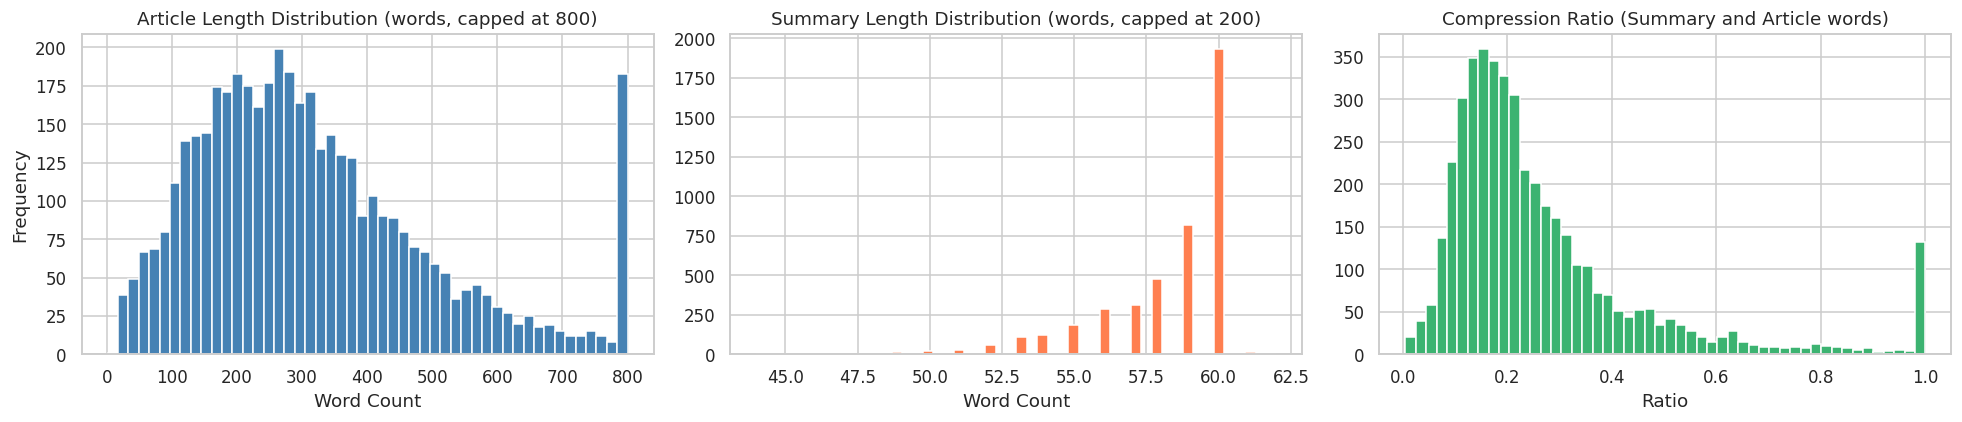

EDA chart saved.


In [53]:
# Compute the word counts for articles and summaries.
df['article_wc'] = df['article'].apply(lambda x: len(str(x).split()))
df['summary_wc'] = df['reference_summary'].apply(lambda x: len(str(x).split()))

print("-------- Article Length Stats (Words) -------")
print(df['article_wc'].describe().round(1).to_string())

print("\n------- Summary Length Stats (Words) -------")
print(df['summary_wc'].describe().round(1).to_string())


# Visualise length distributions for both articles and summaries.
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ------------------------------------------------- PLOT 1: Article Word Count histogram. --------------------------------
axes[0].hist(df['article_wc'].clip(upper=800), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Article Length Distribution (words, capped at 800)')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')

# ------------------------------------------------- PLOT 2: Summary Word Count histogram -------------------------------------------------
axes[1].hist(df['summary_wc'].clip(upper=200), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Summary Length Distribution (words, capped at 200)')
axes[1].set_xlabel('Word Count')

# ------------------------------------------------- PLOT 3: Compression Ratio (Summary words, Article words).
ratio = (df['summary_wc'] / df['article_wc'].replace(0, np.nan)).dropna().clip(upper=1)
axes[2].hist(ratio, bins=50, color='mediumseagreen', edgecolor='white')
axes[2].set_title('Compression Ratio (Summary and Article words)')
axes[2].set_xlabel('Ratio')

plt.tight_layout()
plt.savefig('eda_length_distributions.png', bbox_inches='tight')
plt.show()
print("EDA chart saved.")

In [54]:
# Checking for any missing values and duplicates.
print("Missing values per column:")
print(df[['article', 'reference_summary', 'headlines']].isnull().sum())

n_dupes = df['article'].duplicated().sum()
print(f"\nDuplicate article rows : {n_dupes}")

df.drop_duplicates(subset=['article'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Drop any remaining NaN articles.
df.dropna(subset=['article', 'reference_summary'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Final Cleaned Dataset : {df.shape[0]:,} rows")


Missing values per column:
article              0
reference_summary    0
headlines            0
dtype: int64

Duplicate article rows : 55
Final Cleaned Dataset : 4,341 rows


## 6. Text Preprocessing

In [55]:
def clean_text(text: str) -> str:
    '''
    Cleans a raw news article or summary string.
    Returns a clean, plain-English string ready for tokenisation.
    '''
    # Step 1 : Ensure the input is a string.
    text = str(text)

    # Step 2 : Remove HTML tags and decode HTML entities.

    # Remove <tag> patterns.
    text = re.sub(r'<[^>]+>', ' ', text)  

    # Remove HTML entities like &amp; &nbsp;
    text = re.sub(r'&[a-z]+;', ' ', text)         

    # Step 3 : Remove URLs (http/https links and bare www. links).
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Step 4 : Normalise unicode.
    text = unicodedata.normalize('NFKD', text)
    text = text.encode('ascii', 'ignore').decode('ascii')

    # Step 5 : Replace common Latin-1 mojibake artifacts that survived encoding.

    # Any remaining non-ASCII bytes.
    text = re.sub(r'[\x80-\xff]', ' ', text) 

    # Lone question marks from bad decoding.
    text = re.sub(r'\?', ' ', text)               

    # Step 6 : Collapse multiple whitespace characters (spaces, tabs, newlines) into one space.
    text = re.sub(r'\s+', ' ', text)

    # Step 7 : Strip leading and trailing whitespace.
    return text.strip()


# Apply the cleaning function to both the articles and the reference summaries.
print("Cleaning article texts...")
df['article_clean']   = df['article'].apply(clean_text)
print("Cleaning reference summaries...")
df['summary_clean']   = df['reference_summary'].apply(clean_text)

# Quick sanity check to show a before and after example.
idx = 0
print("\n ---------- BEFORE Cleaning ----------")
print(df['article'].iloc[idx][:300])

print()

print("\n ---------- AFTER Cleaning ----------")
print(df['article_clean'].iloc[idx][:300])


Cleaning article texts...
Cleaning reference summaries...

 ---------- BEFORE Cleaning ----------
The Daman and Diu administration on Wednesday withdrew a circular that asked women staff to tie rakhis on male colleagues after the order triggered a backlash from employees and was ripped apart on social media.The union territory?s administration was forced to retreat within 24 hours of issuing the


 ---------- AFTER Cleaning ----------
The Daman and Diu administration on Wednesday withdrew a circular that asked women staff to tie rakhis on male colleagues after the order triggered a backlash from employees and was ripped apart on social media.The union territory s administration was forced to retreat within 24 hours of issuing the


## 7. Load Tokeniser and Inspect Tokenisation

In [56]:
# Load BART tokeniser from Hugging Face Hub.
# This downloads the vocabulary file.
print(f"Loading tokeniser: {MODEL_NAME} ...")
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)

print(f"Vocabulary Size : {tokenizer.vocab_size:,} tokens")
print(f"BOS token : {tokenizer.bos_token} (id={tokenizer.bos_token_id})")
print(f"EOS token : {tokenizer.eos_token} (id={tokenizer.eos_token_id})")
print(f"PAD token : {tokenizer.pad_token} (id={tokenizer.pad_token_id})")

# Demonstrate how tokenisation works on a real example from our dataset.
sample_text = df['article_clean'].iloc[0]

# Tokenise without truncation to see the true token count.
tokens_full = tokenizer(sample_text, add_special_tokens=True)
token_ids   = tokens_full['input_ids']

print(f"Sample article word count : {len(sample_text.split())}")
print(f"Sample article token count : {len(token_ids)}")
print(f"Would be truncated at 1024 tokens: {len(token_ids) > MAX_INPUT_TOKENS}")
print(f"\nFirst 20 token IDs : {token_ids[:20]}")
print(f"Decoded back to text : {tokenizer.decode(token_ids[:20])}")

# Measure token lengths across the SAMPLE of articles we will actually process.
# We avoid tokenising all 100k articles here, that would take too long.
sample_df = df.sample(n=min(SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Working sample size: {len(sample_df)} articles")

# Tokenise sample articles and record their raw (untruncated) token lengths.
token_lengths = []
for art in tqdm(sample_df['article_clean'], desc='Counting tokens'):
    ids = tokenizer(art, add_special_tokens=True, truncation=False)['input_ids']
    token_lengths.append(len(ids))

sample_df['token_len'] = token_lengths

n_truncated = (sample_df['token_len'] > MAX_INPUT_TOKENS).sum()
print(f"\nArticles exceeding {MAX_INPUT_TOKENS} tokens: {n_truncated} / {len(sample_df)} "
      f"({100*n_truncated/len(sample_df):.1f}%)")



Loading tokeniser: facebook/bart-large-cnn ...
Vocabulary Size : 50,265 tokens
BOS token : <s> (id=0)
EOS token : </s> (id=2)
PAD token : <pad> (id=1)
Sample article word count : 368
Sample article token count : 465
Would be truncated at 1024 tokens: False

First 20 token IDs : [0, 133, 8234, 260, 8, 3643, 257, 942, 15, 307, 13666, 10, 18629, 14, 553, 390, 813, 7, 3318, 910]
Decoded back to text : <s>The Daman and Diu administration on Wednesday withdrew a circular that asked women staff to tie r
Working sample size: 1000 articles


Counting tokens:   0%|          | 0/1000 [00:00<?, ?it/s]


Articles exceeding 1024 tokens: 40 / 1000 (4.0%)


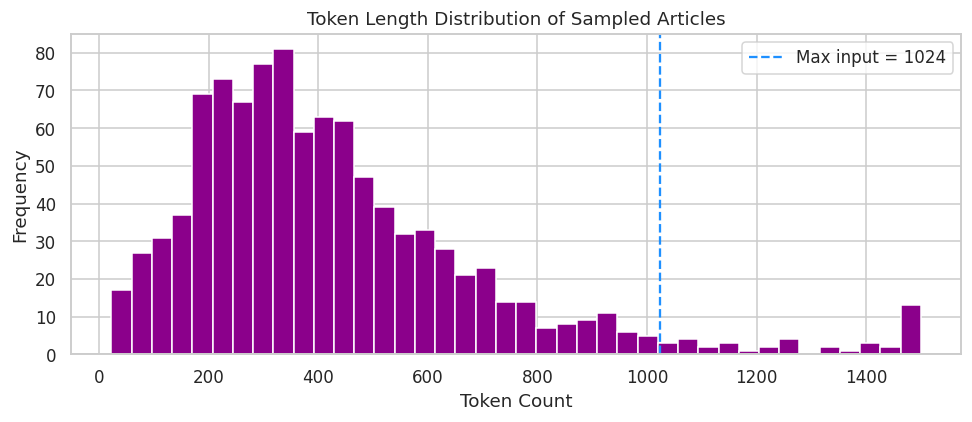

In [57]:
# Visualise token length distribution for the sample.
plt.figure(figsize=(9, 4))
plt.hist(sample_df['token_len'].clip(upper=1500), bins=40, color='darkmagenta', edgecolor='white')
plt.axvline(MAX_INPUT_TOKENS, color='dodgerblue', linestyle='--', label=f'Max input = {MAX_INPUT_TOKENS}')
plt.title('Token Length Distribution of Sampled Articles')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('token_length_distribution.png', bbox_inches='tight')
plt.show()


## 8. Load BART Model and Run Inference

This section loads the pre-trained `facebook/bart-large-cnn` model from 
Hugging Face — a large sequence-to-sequence transformer specifically 
fine-tuned on the CNN/DailyMail news dataset for abstractive summarization.

Unlike extractive methods that copy sentences directly from the article, 
BART uses bidirectional encoding to understand the full context of the 
article and autoregressive decoding to generate new, fluent summary 
sentences word by word.

The model runs inference on our 1000 sampled Inshorts articles, generating 
an abstractive summary for each one. These generated summaries will then 
be compared against the original Inshorts reference summaries using ROUGE 
scores in the next section.

In [58]:

# ── Step 1: Load the pre-trained BART model from Hugging Face ──
# facebook/bart-large-cnn is fine-tuned on CNN/DailyMail news articles
# This downloads ~1.6GB model weights — takes ~1-2 mins on Kaggle
print(f"Loading model: {MODEL_NAME} ...")
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

# ── Step 2: Move model to GPU for faster inference ──
# DEVICE = 'cuda' if GPU available, else 'cpu' (set in Section 2)
model = model.to(DEVICE)
model.eval()  # Set to evaluation mode — disables dropout layers
model.generation_config.forced_bos_token_id = 0
print(f"Model loaded successfully on: {DEVICE}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")


# ── Step 3: Define the summarization function ──
def summarize_article(article_text: str) -> str:
    """
    Takes a raw news article string and returns an abstractive summary.
    Uses beam search to explore multiple output sequences and pick the best.
    
    Args:
        article_text: cleaned news article string
    Returns:
        summary: generated abstractive summary string
    """
    # Tokenize the input article
    # Truncation ensures articles > 1024 tokens are clipped
    inputs = tokenizer(
        article_text,
        max_length=MAX_INPUT_TOKENS,
        truncation=TRUNCATION,
        padding=PADDING,
        return_tensors='pt'   # Return PyTorch tensors
    ).to(DEVICE)              # Move inputs to same device as model
    
    # Generate summary using beam search
    with torch.no_grad():    # Disable gradient calculation (inference only)
        summary_ids = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            num_beams=BEAM_SIZE,           # Explore 4 beams simultaneously
            min_length=MIN_SUMMARY_LEN,    # Avoid too-short summaries
            max_length=MAX_SUMMARY_LEN,    # Cap at 150 tokens
            length_penalty=LENGTH_PENALTY, # Favour longer summaries
            no_repeat_ngram_size=NO_REPEAT_NGRAM,  # Avoid repetition
            early_stopping=EARLY_STOPPING  # Stop when all beams hit EOS
        )
    
    # Decode the generated token IDs back to readable text
    summary = tokenizer.decode(
        summary_ids[0],
        skip_special_tokens=True  # Remove <s>, </s>, <pad> tokens
    )
    return summary

# ── Step 4: Run inference on all 200 sampled articles ──
# This loops through each article, generates a summary, stores results
print(f"\nRunning inference on {len(sample_df)} articles...")
print("This may take 10-15 minutes on GPU — please wait...\n")

generated_summaries = []  # Store generated summaries

for idx, row in tqdm(sample_df.iterrows(), 
                     total=len(sample_df), 
                     desc='Summarizing articles'):
    
    # Generate summary for this article
    summary = summarize_article(row['article_clean'])
    generated_summaries.append(summary)

# ── Step 5: Add generated summaries back to sample dataframe ──
sample_df['generated_summary'] = generated_summaries

print(f"\n✅ Inference complete! Generated {len(generated_summaries)} summaries.")

# ── Step 6: Display 3 example results ──
print("\n" + "="*80)
print("SAMPLE RESULTS — Article vs Generated Summary vs Reference Summary")
print("="*80)

for i in range(3):
    row = sample_df.iloc[i]
    print(f"\n📰 EXAMPLE {i+1}")
    print(f"{'─'*80}")
    print(f"📌 HEADLINE:\n{row['headlines']}")
    print(f"\n📄 ARTICLE (first 200 chars):\n{row['article_clean'][:200]}...")
    print(f"\n🤖 BART GENERATED SUMMARY:\n{row['generated_summary']}")
    print(f"\n✂️  INSHORTS REFERENCE SUMMARY:\n{row['summary_clean']}")
    print(f"{'─'*80}")

Loading model: facebook/bart-large-cnn ...


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

Model loaded successfully on: cuda
Model parameters: 406,290,432

Running inference on 1000 articles...
This may take 10-15 minutes on GPU — please wait...



Summarizing articles:   0%|          | 0/1000 [00:00<?, ?it/s]


✅ Inference complete! Generated 1000 summaries.

SAMPLE RESULTS — Article vs Generated Summary vs Reference Summary

📰 EXAMPLE 1
────────────────────────────────────────────────────────────────────────────────
📌 HEADLINE:
Samsung denies report of selling refurbished Galaxy Note 7

📄 ARTICLE (first 200 chars):
If you are a Samsung Galaxy Note fan, you were waiting to hear these words -- Note 7 will be sold in India. Despite all the bad whether it went through before being laid to the grave, Note 7 might com...

🤖 BART GENERATED SUMMARY:
Samsung has denied that it has any plans to sell refurbished Galaxy Note 7 units in India. Samsung initially announced a recall of some 2.5 million Note 7 phones in September and identified the cause of the fire as a manufacturing process problem at one of its suppliers.

✂️  INSHORTS REFERENCE SUMMARY:
South Korean tech giant Samsung has refuted a report that claimed the company plans to sell refurbished units of the Galaxy Note 7 in India. The report 

## 9. ROUGE Evaluation

Once BART has generated summaries for all 200 sampled articles, we evaluate 
their quality by comparing them against the original Inshorts reference 
summaries using the ROUGE metric (Recall-Oriented Understudy for Gisting 
Evaluation).

ROUGE measures the overlap between the generated summary and the reference 
summary using three key metrics:

- **ROUGE-1**: Overlap of individual words (unigrams) between generated 
  and reference summary
- **ROUGE-2**: Overlap of two-word pairs (bigrams) — captures phrase-level 
  similarity
- **ROUGE-L**: Longest Common Subsequence — measures sentence-level 
  structural similarity

Each score is reported as Precision, Recall and F1-score:
- **Precision** — how much of the generated summary matches the reference
- **Recall** — how much of the reference summary is captured in the generated
- **F1** — harmonic mean of precision and recall (main metric we report)

Higher ROUGE scores indicate the generated summary is closer to the 
human-written Inshorts reference summary.

In [60]:
# ── Step 1: Initialise the ROUGE scorer ──
# We evaluate ROUGE-1, ROUGE-2 and ROUGE-L
scorer = rouge_scorer.RougeScorer(
    ['rouge1', 'rouge2', 'rougeL'], 
    use_stemmer=True  # Stemming helps match word variations (e.g. running → run)
)

# ── Step 2: Calculate ROUGE scores for all 200 articles ──
print("Calculating ROUGE scores for all 1000 summaries...")

# Store individual scores for each article
rouge1_scores = []
rouge2_scores = []
rougeL_scores = []

for idx, row in tqdm(sample_df.iterrows(), 
                     total=len(sample_df),
                     desc='Calculating ROUGE'):
    
    # Compare generated summary vs Inshorts reference summary
    scores = scorer.score(
        row['summary_clean'],      # Reference summary (Inshorts ground truth)
        row['generated_summary']   # Generated summary (BART output)
    )
    
    # Store F1 scores for each metric
    rouge1_scores.append(scores['rouge1'].fmeasure)
    rouge2_scores.append(scores['rouge2'].fmeasure)
    rougeL_scores.append(scores['rougeL'].fmeasure)

# ── Step 3: Add scores to dataframe ──
sample_df['rouge1'] = rouge1_scores
sample_df['rouge2'] = rouge2_scores
sample_df['rougeL'] = rougeL_scores

# ── Step 4: Calculate and display average scores ──
avg_rouge1 = sum(rouge1_scores) / len(rouge1_scores)
avg_rouge2 = sum(rouge2_scores) / len(rouge2_scores)
avg_rougeL = sum(rougeL_scores) / len(rougeL_scores)

print("\n" + "="*50)
print("        ROUGE EVALUATION RESULTS")
print("="*50)
print(f"  ROUGE-1 F1 Score : {avg_rouge1:.4f} ({avg_rouge1*100:.2f}%)")
print(f"  ROUGE-2 F1 Score : {avg_rouge2:.4f} ({avg_rouge2*100:.2f}%)")
print(f"  ROUGE-L F1 Score : {avg_rougeL:.4f} ({avg_rougeL*100:.2f}%)")
print("="*50)

# ── Step 5: Show best and worst performing summaries ──
print("\n🏆 TOP 3 BEST Summaries (highest ROUGE-1):")
print("─"*50)
top3 = sample_df.nlargest(3, 'rouge1')
for i, (_, row) in enumerate(top3.iterrows(), 1):
    print(f"\n#{i} ROUGE-1: {row['rouge1']:.4f}")
    print(f"📌 Headline: {row['headlines']}")
    print(f"🤖 Generated: {row['generated_summary'][:150]}...")
    print(f"✂️  Reference: {row['summary_clean'][:150]}...")

print("\n⚠️ TOP 3 WORST Summaries (lowest ROUGE-1):")
print("─"*50)
bottom3 = sample_df.nsmallest(3, 'rouge1')
for i, (_, row) in enumerate(bottom3.iterrows(), 1):
    print(f"\n#{i} ROUGE-1: {row['rouge1']:.4f}")
    print(f"📌 Headline: {row['headlines']}")
    print(f"🤖 Generated: {row['generated_summary'][:150]}...")
    print(f"✂️  Reference: {row['summary_clean'][:150]}...")

Calculating ROUGE scores for all 1000 summaries...


Calculating ROUGE:   0%|          | 0/1000 [00:00<?, ?it/s]


        ROUGE EVALUATION RESULTS
  ROUGE-1 F1 Score : 0.4244 (42.44%)
  ROUGE-2 F1 Score : 0.2056 (20.56%)
  ROUGE-L F1 Score : 0.3052 (30.52%)

🏆 TOP 3 BEST Summaries (highest ROUGE-1):
──────────────────────────────────────────────────

#1 ROUGE-1: 0.8855
📌 Headline: China building high-speed rail tunnel below Great Wall
🤖 Generated: China is constructing a 12-km-long high-speed train tunnel through one of the portions of its iconic Great Wall. The tunnel will connect Zhangjiakou c...
✂️  Reference: China is reportedly constructing a 12-km-long high-speed train tunnel through one of the portions of its iconic Great Wall to connect Beijing with Zha...

#2 ROUGE-1: 0.8454
📌 Headline: West Indies' Marlon Samuels cleared to bowl in int'l cricket
🤖 Generated: West Indies all-rounder Marlon Samuels cleared to bowl in international cricket. The 36-year-old was last reported for bowling action during the Galle...
✂️  Reference: West Indies all-rounder Marlon Samuels has been cleared to bowl

## 10. Results Visualisation

This section visualises the ROUGE evaluation results to provide a clearer 
understanding of the model's summarization performance across all 1000 
sampled articles.

Four visualisations are produced:
- **ROUGE Score Distribution** — histogram showing spread of scores
- **ROUGE Metrics Comparison** — bar chart comparing average scores
- **Summary Length Comparison** — generated vs reference summary lengths
- **Score Correlation** — relationship between ROUGE-1 and ROUGE-L scores

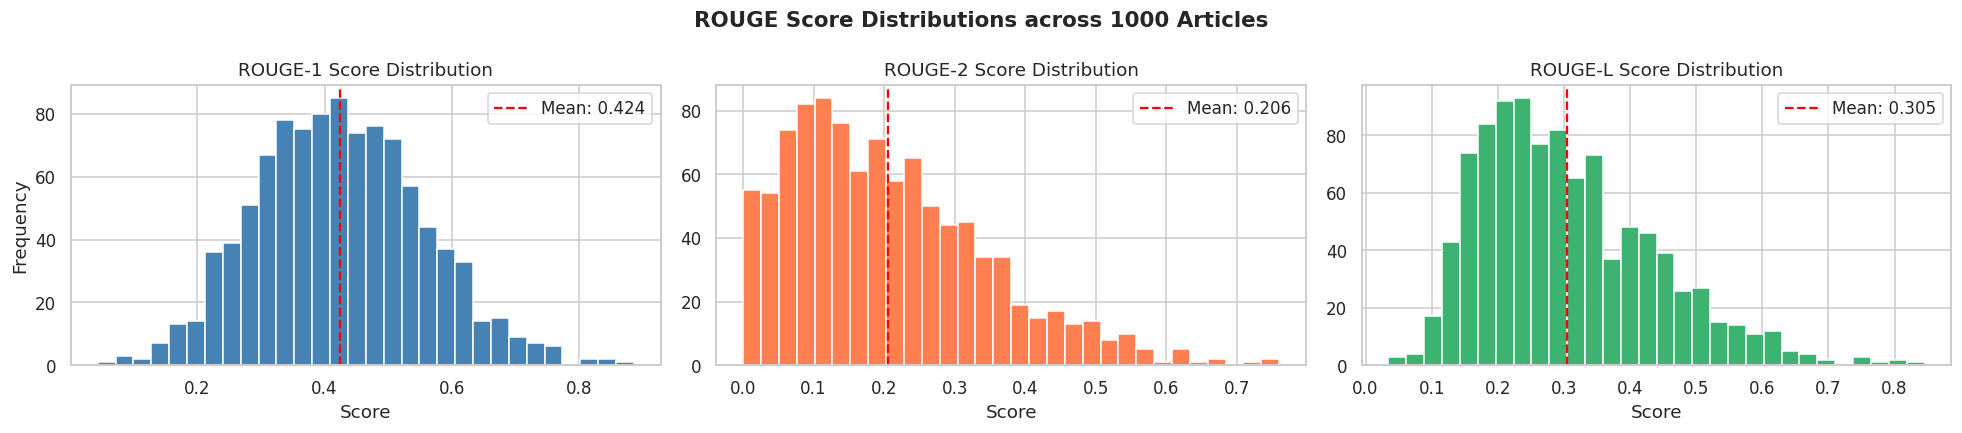

Plot 1 saved.


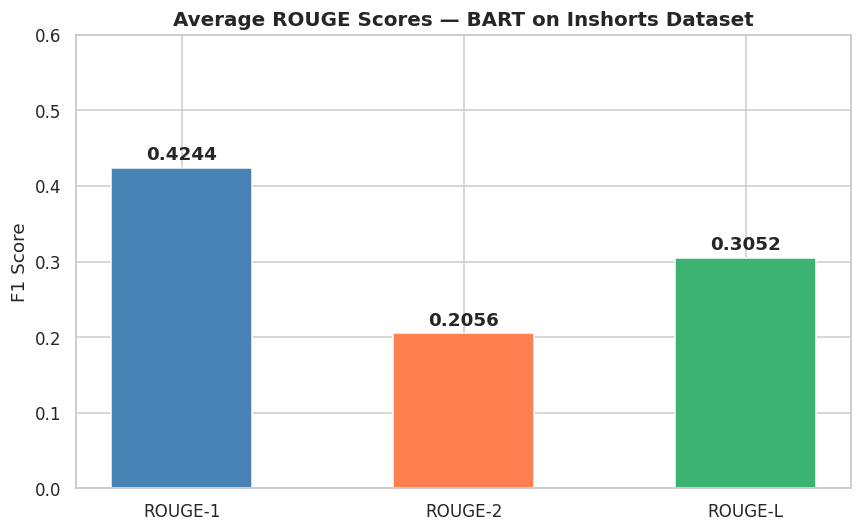

Plot 2 saved.


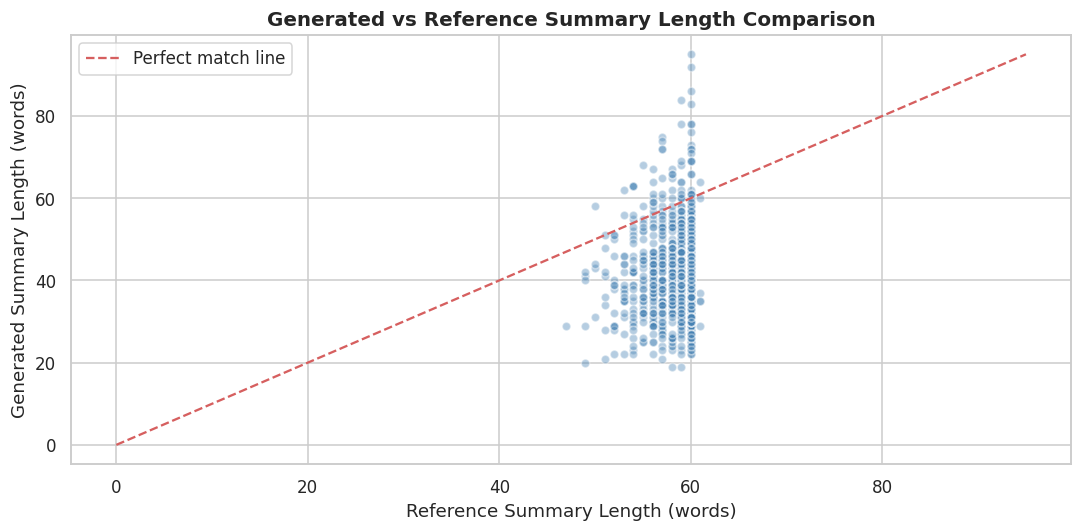

Plot 3 saved.


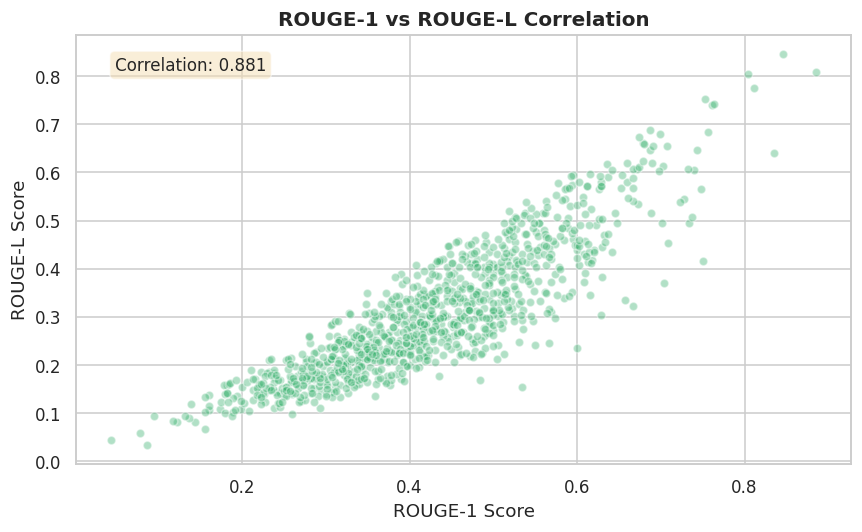

Plot 4 saved.

      FINAL RESULTS SUMMARY
  Total articles evaluated : 1000
  Avg ROUGE-1              : 0.4244
  Avg ROUGE-2              : 0.2056
  Avg ROUGE-L              : 0.3052
  Best ROUGE-1             : 0.8855
  Worst ROUGE-1            : 0.0440
  Avg Generated Length     : 42.0 words
  Avg Reference Length     : 58.2 words


In [62]:
# Set visual style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── Plot 1: ROUGE Score Distributions (histogram) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(sample_df['rouge1'], bins=30, 
             color='steelblue', edgecolor='white')
axes[0].axvline(sample_df['rouge1'].mean(), 
                color='red', linestyle='--', 
                label=f"Mean: {sample_df['rouge1'].mean():.3f}")
axes[0].set_title('ROUGE-1 Score Distribution')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(sample_df['rouge2'], bins=30, 
             color='coral', edgecolor='white')
axes[1].axvline(sample_df['rouge2'].mean(), 
                color='red', linestyle='--',
                label=f"Mean: {sample_df['rouge2'].mean():.3f}")
axes[1].set_title('ROUGE-2 Score Distribution')
axes[1].set_xlabel('Score')
axes[1].legend()

axes[2].hist(sample_df['rougeL'], bins=30, 
             color='mediumseagreen', edgecolor='white')
axes[2].axvline(sample_df['rougeL'].mean(), 
                color='red', linestyle='--',
                label=f"Mean: {sample_df['rougeL'].mean():.3f}")
axes[2].set_title('ROUGE-L Score Distribution')
axes[2].set_xlabel('Score')
axes[2].legend()

plt.suptitle('ROUGE Score Distributions across 1000 Articles', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('rouge_distributions.png', bbox_inches='tight')
plt.show()
print("Plot 1 saved.")

# ── Plot 2: Average ROUGE Scores Bar Chart ──
fig, ax = plt.subplots(figsize=(8, 5))

metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores  = [
    sample_df['rouge1'].mean(),
    sample_df['rouge2'].mean(),
    sample_df['rougeL'].mean()
]
colors = ['steelblue', 'coral', 'mediumseagreen']

bars = ax.bar(metrics, scores, color=colors, edgecolor='white', width=0.5)

# Add score labels on top of each bar
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.005,
            f'{score:.4f}', 
            ha='center', va='bottom', 
            fontweight='bold', fontsize=12)

ax.set_title('Average ROUGE Scores — BART on Inshorts Dataset', 
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.savefig('rouge_bar_chart.png', bbox_inches='tight')
plt.show()
print("Plot 2 saved.")

# ── Plot 3: Generated vs Reference Summary Length ──
fig, ax = plt.subplots(figsize=(10, 5))

# Calculate generated summary word counts
sample_df['generated_wc'] = sample_df['generated_summary'].apply(
    lambda x: len(str(x).split())
)

ax.scatter(sample_df['summary_wc'], 
           sample_df['generated_wc'],
           alpha=0.4, color='steelblue', edgecolor='white', s=30)

# Add diagonal line — perfect length match
max_val = max(sample_df['summary_wc'].max(), 
              sample_df['generated_wc'].max())
ax.plot([0, max_val], [0, max_val], 
        'r--', label='Perfect match line')

ax.set_xlabel('Reference Summary Length (words)')
ax.set_ylabel('Generated Summary Length (words)')
ax.set_title('Generated vs Reference Summary Length Comparison',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('length_comparison.png', bbox_inches='tight')
plt.show()
print("Plot 3 saved.")

# ── Plot 4: ROUGE-1 vs ROUGE-L Correlation ──
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(sample_df['rouge1'], 
           sample_df['rougeL'],
           alpha=0.4, color='mediumseagreen', edgecolor='white', s=30)

ax.set_xlabel('ROUGE-1 Score')
ax.set_ylabel('ROUGE-L Score')
ax.set_title('ROUGE-1 vs ROUGE-L Correlation',
             fontsize=13, fontweight='bold')

# Add correlation coefficient
corr = sample_df['rouge1'].corr(sample_df['rougeL'])
ax.text(0.05, 0.95, f'Correlation: {corr:.3f}',
        transform=ax.transAxes,
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('rouge_correlation.png', bbox_inches='tight')
plt.show()
print("Plot 4 saved.")

# ── Final Summary Statistics ──
print("\n" + "="*50)
print("      FINAL RESULTS SUMMARY")
print("="*50)
print(f"  Total articles evaluated : {len(sample_df)}")
print(f"  Avg ROUGE-1              : {sample_df['rouge1'].mean():.4f}")
print(f"  Avg ROUGE-2              : {sample_df['rouge2'].mean():.4f}")
print(f"  Avg ROUGE-L              : {sample_df['rougeL'].mean():.4f}")
print(f"  Best ROUGE-1             : {sample_df['rouge1'].max():.4f}")
print(f"  Worst ROUGE-1            : {sample_df['rouge1'].min():.4f}")
print(f"  Avg Generated Length     : {sample_df['generated_wc'].mean():.1f} words")
print(f"  Avg Reference Length     : {sample_df['summary_wc'].mean():.1f} words")
print("="*50)

## 11. Save Results and Model Output

This section saves all experiment results to CSV and the generated 
summaries to a structured output file. These outputs serve as evidence 
of the empirical analysis conducted in this project and will be referenced 
in the report.

The saved files include:
- **results.csv** — all 1000 articles with generated summaries and ROUGE scores
- **rouge_summary.csv** — average ROUGE scores summary table for the report
- **sample_outputs.txt** — human-readable examples of generated summaries

In [67]:
# ── Step 1: Save full results dataframe to CSV ──
# Contains all articles, generated summaries and ROUGE scores
output_csv = 'results.csv'
sample_df[[
    'headlines',
    'article_clean',
    'summary_clean',
    'generated_summary',
    'rouge1',
    'rouge2',
    'rougeL',
    'generated_wc',
    'summary_wc'
]].to_csv(output_csv, index=False)
print(f"✅ Full results saved to: {output_csv}")

# ── Step 2: Save ROUGE summary table ──
# This is the table that goes directly into the report
rouge_summary = {
    'Metric': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
    'F1 Score': [
        round(sample_df['rouge1'].mean(), 4),
        round(sample_df['rouge2'].mean(), 4),
        round(sample_df['rougeL'].mean(), 4)
    ],
    'Percentage': [
        f"{sample_df['rouge1'].mean()*100:.2f}%",
        f"{sample_df['rouge2'].mean()*100:.2f}%",
        f"{sample_df['rougeL'].mean()*100:.2f}%"
    ],
    'Best Score': [
        round(sample_df['rouge1'].max(), 4),
        round(sample_df['rouge2'].max(), 4),
        round(sample_df['rougeL'].max(), 4)
    ],
    'Worst Score': [
        round(sample_df['rouge1'].min(), 4),
        round(sample_df['rouge2'].min(), 4),
        round(sample_df['rougeL'].min(), 4)
    ]
}

rouge_df = pd.DataFrame(rouge_summary)
rouge_df.to_csv('rouge_summary.csv', index=False)
print(f"✅ ROUGE summary saved to: rouge_summary.csv")
print("\n" + rouge_df.to_string(index=False))

# ── Step 3: Save human-readable sample outputs ──
# 5 best + 5 worst + 5 random examples for report
output_txt = 'sample_outputs.txt'

with open(output_txt, 'w') as f:
    f.write("="*80 + "\n")
    f.write("ABSTRACTIVE NEWS SUMMARIZATION — BART SAMPLE OUTPUTS\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Model: {MODEL_NAME}\n")
    f.write(f"Dataset: Inshorts News Summary (Kaggle)\n")
    f.write(f"Sample Size: {len(sample_df)} articles\n")
    f.write("="*80 + "\n\n")
    
    # ROUGE Summary
    f.write("ROUGE EVALUATION SUMMARY\n")
    f.write("-"*40 + "\n")
    f.write(f"ROUGE-1 : {sample_df['rouge1'].mean():.4f} ({sample_df['rouge1'].mean()*100:.2f}%)\n")
    f.write(f"ROUGE-2 : {sample_df['rouge2'].mean():.4f} ({sample_df['rouge2'].mean()*100:.2f}%)\n")
    f.write(f"ROUGE-L : {sample_df['rougeL'].mean():.4f} ({sample_df['rougeL'].mean()*100:.2f}%)\n\n")
    
    # Top 5 best examples
    f.write("="*80 + "\n")
    f.write("TOP 5 BEST SUMMARIES (Highest ROUGE-1)\n")
    f.write("="*80 + "\n\n")
    for i, (_, row) in enumerate(sample_df.nlargest(5, 'rouge1').iterrows(), 1):
        f.write(f"EXAMPLE {i} — ROUGE-1: {row['rouge1']:.4f}\n")
        f.write(f"Headline  : {row['headlines']}\n")
        f.write(f"Generated : {row['generated_summary']}\n")
        f.write(f"Reference : {row['summary_clean']}\n")
        f.write("-"*80 + "\n\n")
    
    # Top 5 worst examples
    f.write("="*80 + "\n")
    f.write("TOP 5 WORST SUMMARIES (Lowest ROUGE-1)\n")
    f.write("="*80 + "\n\n")
    for i, (_, row) in enumerate(sample_df.nsmallest(5, 'rouge1').iterrows(), 1):
        f.write(f"EXAMPLE {i} — ROUGE-1: {row['rouge1']:.4f}\n")
        f.write(f"Headline  : {row['headlines']}\n")
        f.write(f"Generated : {row['generated_summary']}\n")
        f.write(f"Reference : {row['summary_clean']}\n")
        f.write("-"*80 + "\n\n")
    
    # 5 random examples
    f.write("="*80 + "\n")
    f.write("5 RANDOM EXAMPLES\n")
    f.write("="*80 + "\n\n")
    for i, (_, row) in enumerate(sample_df.sample(5, random_state=42).iterrows(), 1):
        f.write(f"EXAMPLE {i} — ROUGE-1: {row['rouge1']:.4f}\n")
        f.write(f"Headline  : {row['headlines']}\n")
        f.write(f"Generated : {row['generated_summary']}\n")
        f.write(f"Reference : {row['summary_clean']}\n")
        f.write("-"*80 + "\n\n")

print(f"✅ Sample outputs saved to: {output_txt}")

# ── Step 4: Save experiment config as JSON ──
# Good practice — records exactly what settings were used
config = {
    'model_name': MODEL_NAME,
    'sample_size': len(sample_df),
    'max_input_tokens': MAX_INPUT_TOKENS,
    'min_summary_len': MIN_SUMMARY_LEN,
    'max_summary_len': MAX_SUMMARY_LEN,
    'beam_size': BEAM_SIZE,
    'length_penalty': LENGTH_PENALTY,
    'no_repeat_ngram': NO_REPEAT_NGRAM,
    'rouge1_mean': round(sample_df['rouge1'].mean(), 4),
    'rouge2_mean': round(sample_df['rouge2'].mean(), 4),
    'rougeL_mean': round(sample_df['rougeL'].mean(), 4),
    'dataset': 'Inshorts News Summary (Kaggle)',
    'generated_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('experiment_config.json', 'w') as f:
    json.dump(config, f, indent=4)
print(f"✅ Experiment config saved to: experiment_config.json")

# ── Step 5: List all saved output files ──
import os
print("\n📁 All saved output files:")
for f in ['results.csv', 'rouge_summary.csv', 
          'sample_outputs.txt', 'experiment_config.json',
          'eda_length_distributions.png', 'rouge_distributions.png',
          'rouge_bar_chart.png', 'length_comparison.png',
          'rouge_correlation.png']:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  ✅ {f} ({size:.1f} KB)")
    else:
        print(f"  ❌ {f} — not found")

print("\n🎉 All outputs saved! Notebook complete.")
print("Download outputs from Kaggle Output panel on the right →")

✅ Full results saved to: results.csv
✅ ROUGE summary saved to: rouge_summary.csv

 Metric  F1 Score Percentage  Best Score  Worst Score
ROUGE-1    0.4244     42.44%      0.8855       0.0440
ROUGE-2    0.2056     20.56%      0.7600       0.0000
ROUGE-L    0.3052     30.52%      0.8454       0.0345
✅ Sample outputs saved to: sample_outputs.txt
✅ Experiment config saved to: experiment_config.json

📁 All saved output files:
  ✅ results.csv (2718.1 KB)
  ✅ rouge_summary.csv (0.1 KB)
  ✅ sample_outputs.txt (13.7 KB)
  ✅ experiment_config.json (0.4 KB)
  ✅ eda_length_distributions.png (61.6 KB)
  ✅ rouge_distributions.png (50.4 KB)
  ✅ rouge_bar_chart.png (26.3 KB)
  ✅ length_comparison.png (78.6 KB)
  ✅ rouge_correlation.png (98.5 KB)

🎉 All outputs saved! Notebook complete.
Download outputs from Kaggle Output panel on the right →


In [68]:
import os

# List all output files
print("Files in /kaggle/working:")
for f in os.listdir('/kaggle/working'):
    size = os.path.getsize(f'/kaggle/working/{f}') / 1024
    print(f"  {f} ({size:.1f} KB)")

Files in /kaggle/working:
  token_length_distribution.png (29.7 KB)
  eda_length_distributions.png (61.6 KB)
  rouge_summary.csv (0.1 KB)
  length_comparison.png (78.6 KB)
  rouge_correlation.png (98.5 KB)
  rouge_bar_chart.png (26.3 KB)
  .virtual_documents (4.0 KB)
  rouge_distributions.png (50.4 KB)
  sample_outputs.txt (13.7 KB)
  results.csv (2718.1 KB)
  experiment_config.json (0.4 KB)
